In [2]:
# Import required packages
import cv2
import pytesseract

# Mention the installed location of Tesseract-OCR in your system
pytesseract.pytesseract.tesseract_cmd = '/bin/tesseract'  # In case using colab after installing above modules

# Read image from which text needs to be extracted
img = cv2.imread("tanmay kendre.jpg")

# Preprocessing the image starts

# Convert the image to gray scale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Performing OTSU threshold
ret, thresh1 = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU | cv2.THRESH_BINARY_INV)

# Specify structure shape and kernel size. 
# Kernel size increases or decreases the area 
# of the rectangle to be detected.
# A smaller value like (10, 10) will detect 
# each word instead of a sentence.
rect_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (18, 18))

# Applying dilation on the threshold image
dilation = cv2.dilate(thresh1, rect_kernel, iterations = 1)

# Finding contours
contours, hierarchy = cv2.findContours(dilation, cv2.RETR_EXTERNAL, 
                                                 cv2.CHAIN_APPROX_NONE)

# Creating a copy of image
im2 = img.copy()

# A text file is created and flushed
file = open("recognized.txt", "w+")
file.write("")
file.close()

# Looping through the identified contours
# Then rectangular part is cropped and passed on
# to pytesseract for extracting text from it
# Extracted text is then written into the text file
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    
    # Drawing a rectangle on copied image
    rect = cv2.rectangle(im2, (x, y), (x + w, y + h), (0, 255, 0), 2)
    
    # Cropping the text block for giving input to OCR
    cropped = im2[y:y + h, x:x + w]
    
    # Open the file in append mode
    file = open("recognized.txt", "a")
    
    # Apply OCR on the cropped image
    text = pytesseract.image_to_string(cropped)
    
    # Appending the text into file
    file.write(text)
    file.write("\n")
    
    # Close the file
    file.close()

# This code is modified by Susobhan Akhuli


error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [3]:
# Import required packages
import cv2
import pytesseract

# Mention the installed location of Tesseract-OCR in your system
pytesseract.pytesseract.tesseract_cmd = '/bin/tesseract'  # In case using colab after installing above modules

# Read image from which text needs to be extracted
img = cv2.imread("tanmay kendre.jpg")

# Preprocessing the image starts

# Convert the image to gray scale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Performing OTSU threshold
ret, thresh1 = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU | cv2.THRESH_BINARY_INV)

# Specify structure shape and kernel size. 
# Kernel size increases or decreases the area 
# of the rectangle to be detected.
# A smaller value like (10, 10) will detect 
# each word instead of a sentence.
rect_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (18, 18))

# Applying dilation on the threshold image
dilation = cv2.dilate(thresh1, rect_kernel, iterations = 1)

# Finding contours
contours, hierarchy = cv2.findContours(dilation, cv2.RETR_EXTERNAL, 
                                                 cv2.CHAIN_APPROX_NONE)

# Creating a copy of image
im2 = img.copy()

# A text file is created and flushed
file = open("recognized.txt", "w+")
file.write("")
file.close()

# Looping through the identified contours
# Then rectangular part is cropped and passed on
# to pytesseract for extracting text from it
# Extracted text is then written into the text file
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    
    # Drawing a rectangle on copied image
    rect = cv2.rectangle(im2, (x, y), (x + w, y + h), (0, 255, 0), 2)
    
    # Cropping the text block for giving input to OCR
    cropped = im2[y:y + h, x:x + w]
    
    # Open the file in append mode
    file = open("recognized.txt", "a")
    
    # Apply OCR on the cropped image
    text = pytesseract.image_to_string(cropped)
    
    # Appending the text into file
    file.write(text)
    file.write("\n")
    
    # Close the file
    file.close()

# This code is modified by Susobhan Akhuli


error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [5]:
import cv2
import easyocr
import matplotlib.pyplot as plt

# Initialize the EasyOCR reader with the desired language (e.g., 'en' for English)
reader = easyocr.Reader(['en'])

# Read the image using OpenCV
image_path = "C:/Users/vaibh/Downloads/tanmay kendre.jpg"
img = cv2.imread(image_path)

# Convert the image to grayscale (optional, EasyOCR can handle colored images too)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Perform thresholding to enhance the image if needed (optional)
ret, thresh1 = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU | cv2.THRESH_BINARY_INV)

# Use EasyOCR to detect and read text from the image
result = reader.readtext(thresh1)

# Open a file to save the recognized text
with open("recognized_easyocr.txt", "w") as file:
    for detection in result:
        # Extract the text and confidence from the result
        text = detection[1]
        confidence = detection[2]
        
        # Write the detected text into the file
        file.write(f"Detected Text: {text}, Confidence: {confidence}\n")
        
        # Get the bounding box for the detected text
        top_left = tuple(detection[0][0])
        bottom_right = tuple(detection[0][2])
        
        # Draw a rectangle around the detected text
        cv2.rectangle(img, top_left, bottom_right, (0, 255, 0), 2)

# Optionally, display the image with bounding boxes
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


error: OpenCV(4.10.0) :-1: error: (-5:Bad argument) in function 'rectangle'
> Overload resolution failed:
>  - Can't parse 'pt1'. Sequence item with index 0 has a wrong type
>  - Can't parse 'pt1'. Sequence item with index 0 has a wrong type
>  - Can't parse 'rec'. Expected sequence length 4, got 2
>  - Can't parse 'rec'. Expected sequence length 4, got 2


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


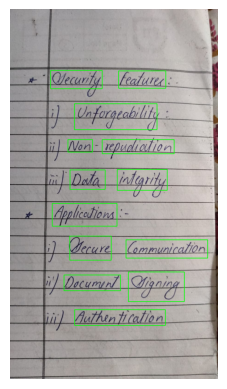

In [6]:
import cv2
import easyocr
import matplotlib.pyplot as plt

# Initialize the EasyOCR reader with the desired language (e.g., 'en' for English)
reader = easyocr.Reader(['en'])

# Read the image using OpenCV
image_path = "C:/Users/vaibh/Downloads/tanmay kendre.jpg"
img = cv2.imread(image_path)

# Convert the image to grayscale (optional)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Use EasyOCR to detect and read text from the image
result = reader.readtext(gray)

# Open a file to save the recognized text
with open("recognized_easyocr.txt", "w") as file:
    for detection in result:
        # Extract the text and confidence from the result
        text = detection[1]
        confidence = detection[2]
        
        # Write the detected text into the file
        file.write(f"Detected Text: {text}, Confidence: {confidence}\n")
        
        # Get the bounding box for the detected text
        top_left = tuple(map(int, detection[0][0]))  # Convert to tuple and integers
        bottom_right = tuple(map(int, detection[0][2]))  # Convert to tuple and integers
        
        # Draw a rectangle around the detected text
        cv2.rectangle(img, top_left, bottom_right, (0, 255, 0), 2)

# Optionally, display the image with bounding boxes
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


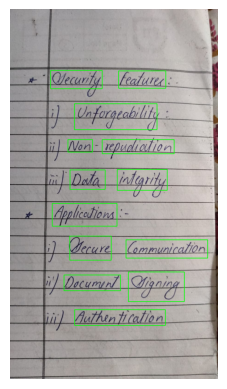

In [7]:
import cv2
import easyocr
import matplotlib.pyplot as plt

# Initialize the EasyOCR reader with the desired language (e.g., 'en' for English)
reader = easyocr.Reader(['en'])

# Read the image using OpenCV
image_path = "C:/Users/vaibh/Downloads/tanmay kendre.jpg"
img = cv2.imread(image_path)

# Check if the image is loaded correctly
if img is None:
    print("Error: Image not found or incorrect path provided.")
else:
    # Convert the image to grayscale (optional)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Use EasyOCR to detect and read text from the grayscale image
    result = reader.readtext(gray)

    # Open a file to save the recognized text
    with open("recognized_easyocr.txt", "w") as file:
        for detection in result:
            # Extract the detected text and confidence from the result
            text = detection[1]
            confidence = detection[2]
            
            # Write the detected text and confidence score into the file
            file.write(f"Detected Text: {text}, Confidence: {confidence}\n")
            
            # Get the bounding box for the detected text
            top_left = tuple(map(int, detection[0][0]))  # Convert coordinates to integers
            bottom_right = tuple(map(int, detection[0][2]))  # Convert coordinates to integers
            
            # Draw a rectangle around the detected text on the image
            cv2.rectangle(img, top_left, bottom_right, (0, 255, 0), 2)

    # Optionally, display the image with the bounding boxes around the text
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')  # Hide axis
    plt.show()


In [10]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [1]:
import tensorflow as tf


In [2]:
pip install pandas


   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.6 MB 991.0 kB/s eta 0:00:12
    --------------------------------------- 0.2/11.6 MB 2.5 MB/s eta 0:00:05
   - -------------------------------------- 0.5/11.6 MB 3.9 MB/s eta 0:00:03
   -- ------------------------------------- 0.7/11.6 MB 4.5 MB/s eta 0:00:03
   -- ------------------------------------- 0.7/11.6 MB 4.5 MB/s eta 0:00:03
   --- ------------------------------------ 1.0/11.6 MB 4.1 MB/s eta 0:00:03
   ---- ----------------------------------- 1.2/11.6 MB 4.0 MB/s eta 0:00:03
   ---- ----------------------------------- 1.4/11.6 MB 4.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.6/11.6 MB 4.2 MB/s eta 0:00:03
   ------ --------------------------------- 1.9/11.6 MB 4.2 MB/s eta 0:00:03
   ------- -------------------------------- 2.2/11.6 MB 4.4 MB/s eta 0:00:03
   -------- ------------------------------- 2.4/11.6 MB 4.6 MB/s eta 0:00:03
   

In [1]:
import pandas as pd

# Load the CSV file
file_path = 'C:/Users/vaibh/Downloads/gt_test.csv'  # Replace with your file path
df = pd.read_csv(file_path)

# Rename columns for easier processing
df.columns = ['Path_A', 'Path_B', 'Annotations']

# Concatenate columns A and B into a new 'Path' column
df['Path'] = df['Path_A'] + df['Path_B']

# Drop the old 'Path_A' and 'Path_B' columns
df = df[['Path', 'Annotations']]

# Save the modified DataFrame to a new CSV file
output_file_path = 'path_to_modified_file.csv'  # Replace with your desired output path
df.to_csv(output_file_path, index=False)

print("File has been modified and saved.")

File has been modified and saved.


In [2]:
import pandas as pd

# Load the CSV file
file_path = 'C:/Users/vaibh/Downloads/gt_test.csv'  # Replace with your file path
df = pd.read_csv(file_path)

# Rename columns for easier processing
df.columns = ['Path_A', 'Path_B', 'Annotations']

# Concatenate columns A and B into a new 'Path' column
df['Path'] = df['Path_A'] + df['Path_B']

# Drop the old 'Path_A' and 'Path_B' columns
df = df[['Path', 'Annotations']]

# Save the modified DataFrame to a new CSV file
output_file_path = 'path_to_modified_file.csv'  # Replace with your desired output path
df.to_csv(output_file_path, index=False)

print("File has been modified and saved.")

File has been modified and saved.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from emnist import extract_training_samples, extract_test_samples

# Load EMNIST dataset (use 'letters' for example, you can also load 'digits' or other subsets)
X_train, y_train = extract_training_samples('letters')
X_test, y_test = extract_test_samples('letters')

# Check shapes of the dataset
print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

ModuleNotFoundError: No module named 'emnist'

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from emnist import digit-test, digit-train

# Load EMNIST dataset (use 'letters' for example, you can also load 'digits' or other subsets)
X_train, y_train = extract_training_samples('letters')
X_test, y_test = extract_test_samples('letters')

# Check shapes of the dataset
print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

SyntaxError: invalid syntax (3007050424.py, line 3)

In [7]:
import pandas as pd

# Load the dataset (adjust the path to where your CSV file is stored)
data = pd.read_csv('C:/Data Set/emnist-digits-test.csv')

# Check the first few rows of the dataset
print(data.head())

   0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  ...  0.472  0.473  0.474  \
0  9    0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  7    0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  9    0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  2    0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2    0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.475  0.476  0.477  0.478  0.479  0.480  0.481  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]


In [9]:
X = data.iloc[:, 0:].values  # Pixel values
y = data.iloc[:, 0].values   # Labels

print(f"Feature data shape: {X.shape}")
print(f"Labels data shape: {y.shape}")

Feature data shape: (39999, 785)
Labels data shape: (39999,)


In [12]:
import numpy as np

# Reshape the pixel data to 28x28 images
X = X.reshape(-1, 28, 28)

# Normalize the pixel values (0 to 255 to 0 to 1)
X = X.astype('float32') / 255.0

# Reshape for CNNs if needed (add channel dimension)
X = X.reshape(-1, 28, 28, 1)

print(f"Reshaped data shape: {X.shape}")

ValueError: cannot reshape array of size 31399215 into shape (28,28)

In [11]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape the data for TensorFlow (if using CNNs)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"Reshaped training data shape: {X_train.shape}")
print(f"Reshaped test data shape: {X_test.shape}")

NameError: name 'X_train' is not defined

Train: (697931, 785)
Test: (116322, 785)
Map: (62, 1)


C:\Users\vaibh\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         819,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 62)                  │           7,998 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 914,238 (3.49 MB)

 Trainable params: 913,214 (3.48 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/10
17445/17449 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7531 - loss: 1.4083
Epoch 1: val_accuracy improved from -inf to 0.78096, saving model to Best_points.keras
17449/17449 ━━━━━━━━━━━━━━━━━━━━ 185s 10ms/step - accuracy: 0.7531 - loss: 1.4081 - val_accuracy: 0.7810 - val_loss: 0.8185 - learning_rate: 0.0010
Epoch 2/10
17448/17449 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8070 - loss: 0.7399
Epoch 2: val_accuracy improved from 0.78096 to 0.81946, saving model to Best_points.keras
17449/17449 ━━━━━━━━━━━━━━━━━━━━ 180s 10ms/step - accuracy: 0.8070 - loss: 0.7399 - val_accuracy: 0.8195 - val_loss: 0.6827 - learning_rate: 0.0010
Epoch 3/10
17447/17449 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8116 - loss: 0.7006
Epoch 3: val_accuracy did not improve from 0.81946
17449/17449 ━━━━━━━━━━━━━━━━━━━━ 167s 10ms/step - accuracy: 0.8116 - loss: 0.7006 - val_accuracy: 0.8044 - val_loss: 0.6985 - learning_rate: 0.0010
Epoch 4/10
17443/17449 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

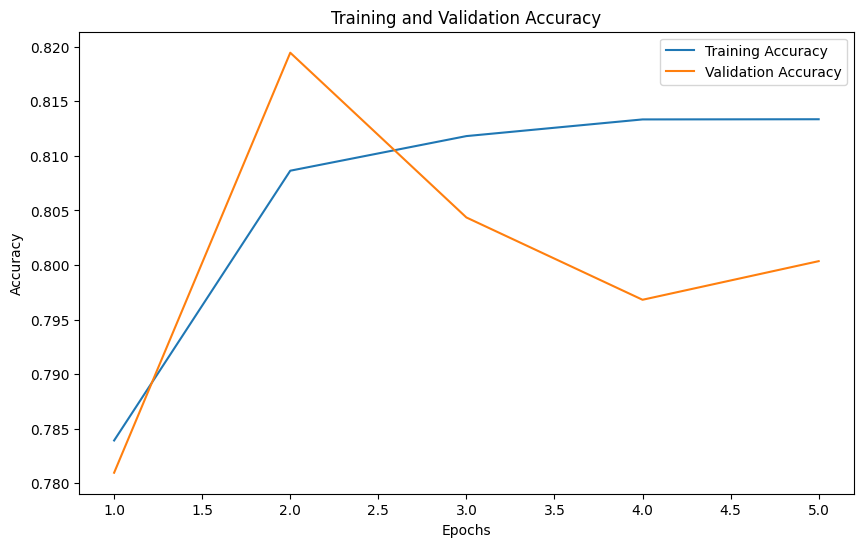

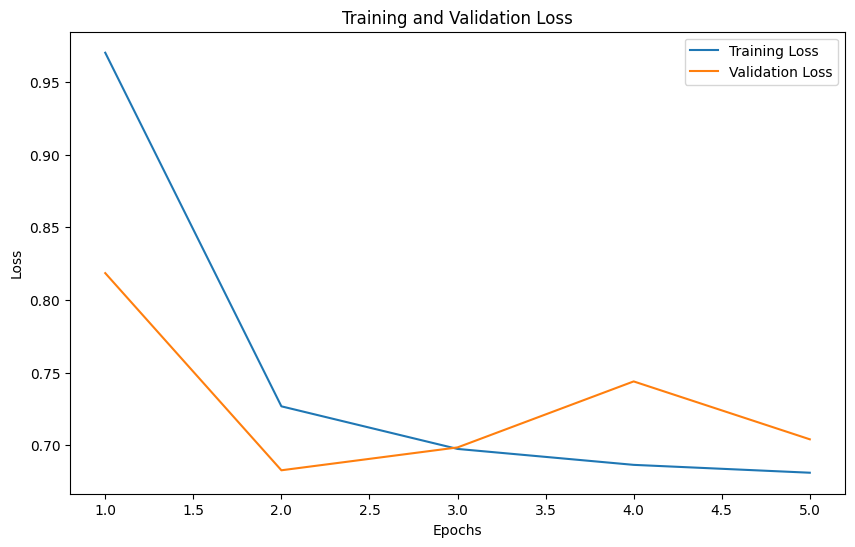

Final Training Accuracy: 0.8133623600006104
Final Validation Accuracy: 0.8003538846969604
3636/3636 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step


C:\Users\vaibh\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


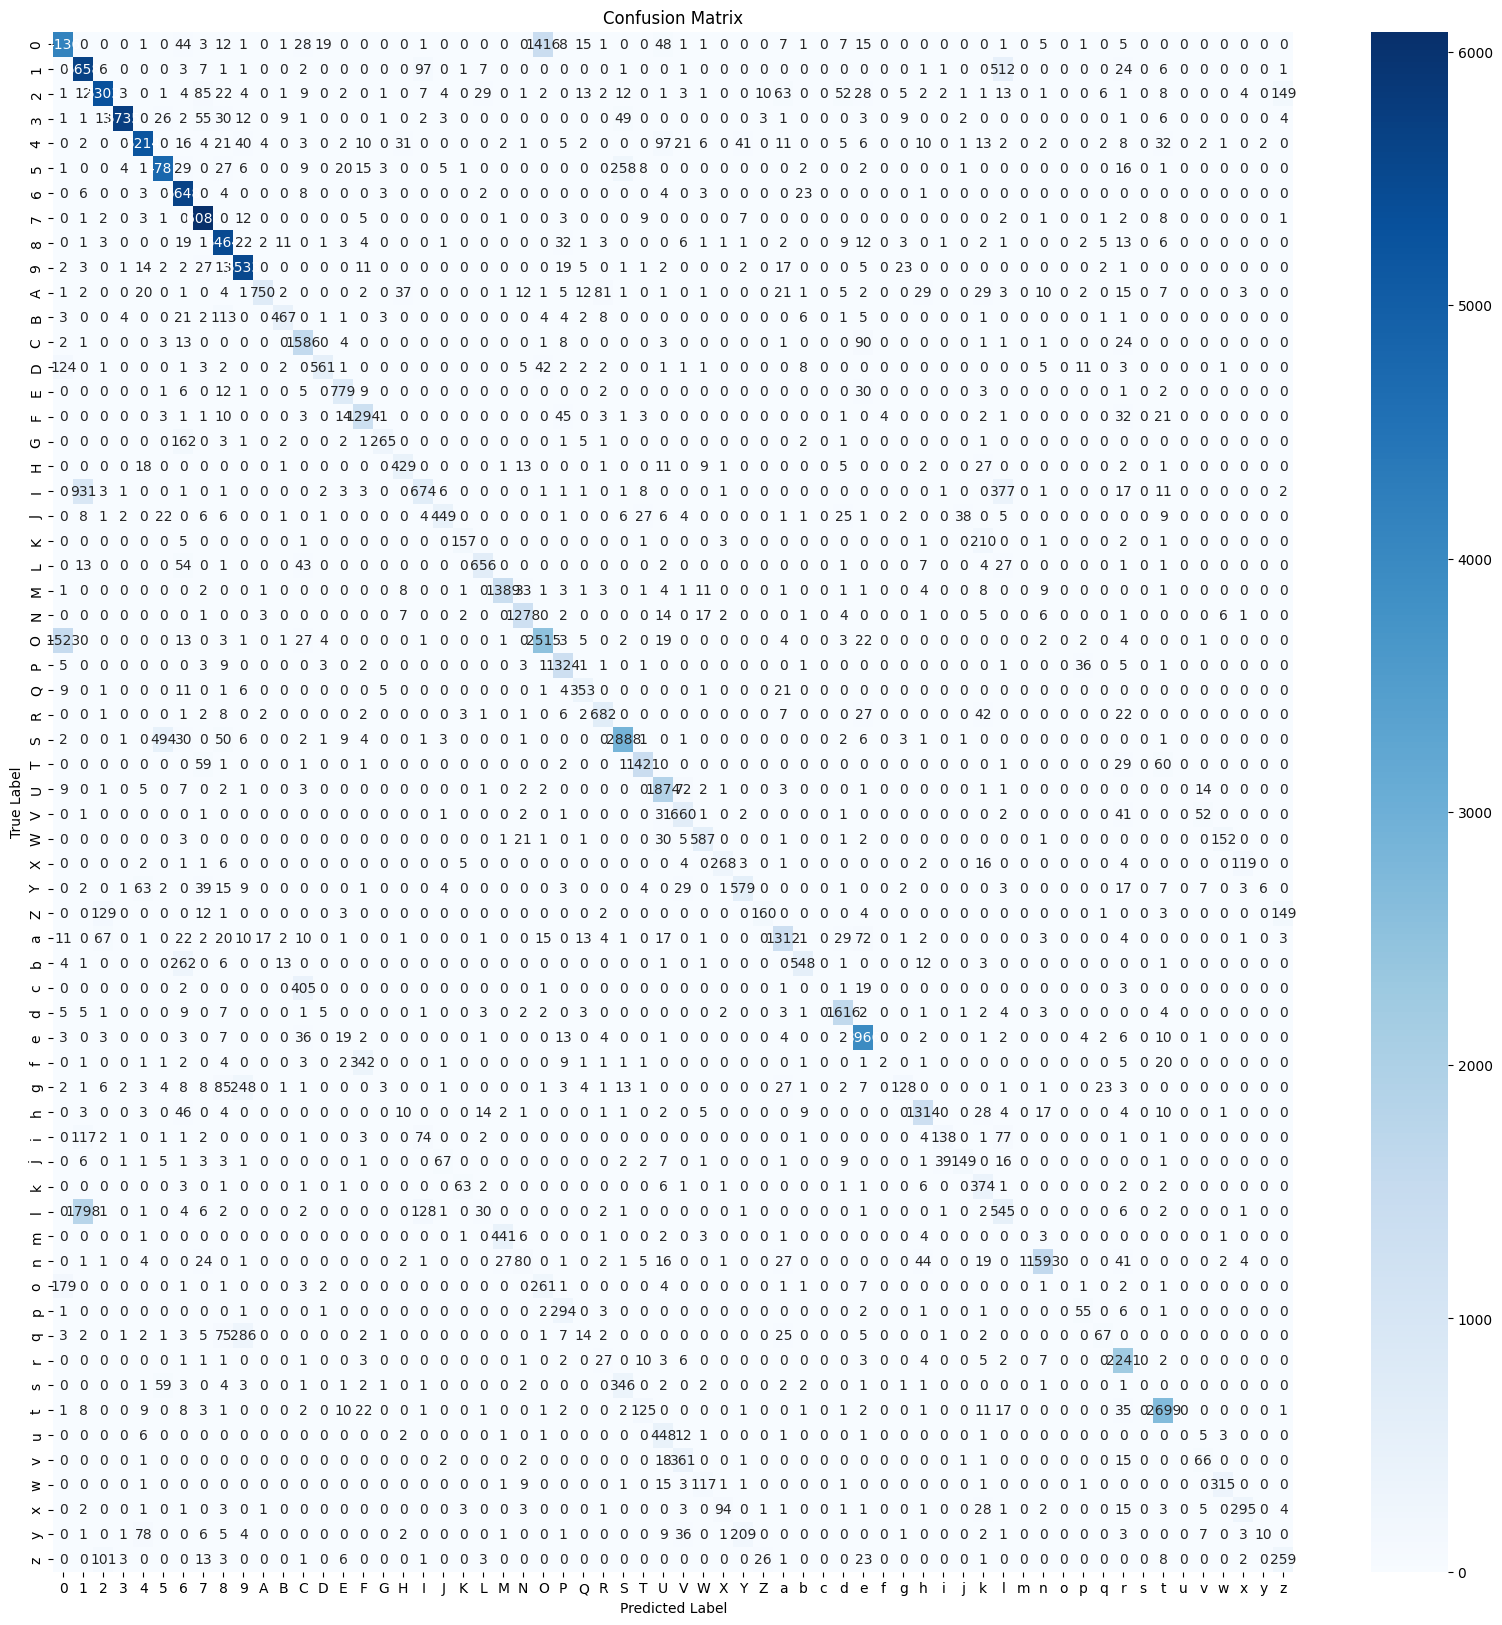

Precision: 0.8006
Recall: 0.8192
F1 Score: 0.8008


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical


warnings.filterwarnings("ignore", category=FutureWarning)


byclass_train = pd.read_csv("C://Data Set//emnist-byclass-train.csv")
byclass_test = pd.read_csv("C://Data Set//emnist-byclass-test.csv")
mapp = pd.read_csv("C://Data Set//emnist-byclass-mapping.txt", delimiter=' ', index_col=0, header=None)


print(f"Train: {byclass_train.shape}\nTest: {byclass_test.shape}\nMap: {mapp.shape}")


keys = range(len(mapp[1].values))
values = [chr(v) for v in mapp[1].values]
map_dict = dict(zip(keys, values))


y1 = np.array(byclass_train.iloc[:, 0].values)
x1 = np.array(byclass_train.iloc[:, 1:].values)
y2 = np.array(byclass_test.iloc[:, 0].values)
x2 = np.array(byclass_test.iloc[:, 1:].values)


x_train = x1 / 255.0
x_test = x2 / 255.0
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)


classes = len(np.unique(np.concatenate([y1, y2])))  
train_y = to_categorical(y1, classes)
test_y = to_categorical(y2, classes)


train_x, val_x, train_y, val_y = train_test_split(x_train, train_y, test_size=0.2, random_state=42)


def create_cnn(activation='relu', batch_norm=True, reg='L2', dropout=0.2):
    model = Sequential()
    
    model.add(layers.Conv2D(32, 3, activation=activation, input_shape=(28, 28, 1), kernel_regularizer=regularizers.L2(0.01)))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Conv2D(64, 3, activation=activation, kernel_regularizer=regularizers.L2(0.01)))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Flatten())
    
    model.add(layers.Dense(512, activation=activation, kernel_regularizer=regularizers.L2(0.01)))
    if batch_norm:
        model.add(layers.BatchNormalization())
    
    model.add(layers.Dense(128, activation=activation, kernel_regularizer=regularizers.L2(0.01)))
    if dropout:
        model.add(layers.Dropout(dropout))
    
    model.add(layers.Dense(classes, activation='softmax'))
    
    return model

model = create_cnn()
model.summary()

optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


MCP = ModelCheckpoint('Best_points.keras', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max')
ES = EarlyStopping(monitor='val_accuracy', min_delta=0, verbose=1, restore_best_weights=True, patience=3, mode='max')
RLP = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, min_lr=0.0001)


history = model.fit(train_x, train_y, epochs=10, validation_data=(val_x, val_y), callbacks=[MCP, ES, RLP])


model.save("emnist_cnn_model.h5")


plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, len(history.history['accuracy']) + 1), y=history.history['accuracy'], label='Training Accuracy')
sns.lineplot(x=range(1, len(history.history['val_accuracy']) + 1), y=history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, len(history.history['loss']) + 1), y=history.history['loss'], label='Training Loss')
sns.lineplot(x=range(1, len(history.history['val_loss']) + 1), y=history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]}")


test_labels = byclass_test.iloc[:, 0]
test_images = byclass_test.iloc[:, 1:].values.astype('float32') / 255.0
test_images = test_images.reshape(-1, 28, 28, 1)
test_labels_onehot = to_categorical(test_labels, num_classes=classes)


y_pred = np.argmax(model.predict(test_images), axis=-1)
cm = confusion_matrix(test_labels, y_pred)
precision, recall, f1_score, _ = precision_recall_fscore_support(test_labels, y_pred, average='weighted')


plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=[map_dict[i] for i in np.unique(test_labels)], 
            yticklabels=[map_dict[i] for i in np.unique(test_labels)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical


# Suppress FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Enable mixed precision (optional, works well on GPUs)
from tensorflow.keras.mixed_precision import experimental as mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_policy(policy)

# Load datasets
byclass_train = pd.read_csv("C://Data Set//emnist-byclass-train.csv")
byclass_test = pd.read_csv("C://Data Set//emnist-byclass-test.csv")
mapp = pd.read_csv("C://Data Set//emnist-byclass-mapping.txt", delimiter=' ', index_col=0, header=None)

# Display dataset shapes
print(f"Train: {byclass_train.shape}\nTest: {byclass_test.shape}\nMap: {mapp.shape}")

# Create mapping dictionary
keys = range(len(mapp[1].values))
values = [chr(v) for v in mapp[1].values]
map_dict = dict(zip(keys, values))

# Separate features and labels for training and testing datasets
y1 = np.array(byclass_train.iloc[:, 0].values)
x1 = np.array(byclass_train.iloc[:, 1:].values)
y2 = np.array(byclass_test.iloc[:, 0].values)
x2 = np.array(byclass_test.iloc[:, 1:].values)

# Normalize and reshape data
x_train = x1 / 255.0
x_test = x2 / 255.0
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Convert labels to categorical
classes = len(np.unique(np.concatenate([y1, y2])))  # Update number of classes based on unique labels
train_y = to_categorical(y1, classes)
test_y = to_categorical(y2, classes)

# Split data into training and validation sets
train_x, val_x, train_y, val_y = train_test_split(x_train, train_y, test_size=0.2, random_state=42)

# Define CNN model with reduced complexity
def create_cnn(activation='relu', batch_norm=True, reg='L2', dropout=0.2):
    model = Sequential()
    
    model.add(layers.Conv2D(32, 3, activation=activation, input_shape=(28, 28, 1), kernel_regularizer=regularizers.L2(0.01)))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Conv2D(64, 3, activation=activation, kernel_regularizer=regularizers.L2(0.01)))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Flatten())
    
    model.add(layers.Dense(256, activation=activation, kernel_regularizer=regularizers.L2(0.01)))  # Reduced units
    if batch_norm:
        model.add(layers.BatchNormalization())
    
    model.add(layers.Dense(64, activation=activation, kernel_regularizer=regularizers.L2(0.01)))  # Reduced units
    if dropout:
        model.add(layers.Dropout(dropout))
    
    model.add(layers.Dense(classes, activation='softmax', dtype='float32'))  # Use float32 for final layer in mixed precision
    
    return model

# Create, compile, and summarize the model
model = create_cnn()
model.summary()

optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
MCP = ModelCheckpoint('Best_points.keras', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max')
ES = EarlyStopping(monitor='val_accuracy', min_delta=0, verbose=1, restore_best_weights=True, patience=3, mode='max')
RLP = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, min_lr=0.0001)

# Train the model with smaller batch size (faster iterations) and early stopping
history = model.fit(train_x, train_y, batch_size=16, epochs=10, validation_data=(val_x, val_y), callbacks=[MCP, ES, RLP])

# Save the trained model
model.save("emnist_cnn_model.h5")

# Plot training and validation accuracy over epochs
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, len(history.history['accuracy']) + 1), y=history.history['accuracy'], label='Training Accuracy')
sns.lineplot(x=range(1, len(history.history['val_accuracy']) + 1), y=history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.show()

# Plot training and validation loss over epochs
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, len(history.history['loss']) + 1), y=history.history['loss'], label='Training Loss')
sns.lineplot(x=range(1, len(history.history['val_loss']) + 1), y=history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]}")

# Load and preprocess test data
test_labels = byclass_test.iloc[:, 0]
test_images = byclass_test.iloc[:, 1:].values.astype('float32') / 255.0
test_images = test_images.reshape(-1, 28, 28, 1)
test_labels_onehot = to_categorical(test_labels, num_classes=classes)

# Model evaluation with confusion matrix and metrics
y_pred = np.argmax(model.predict(test_images), axis=-1)
cm = confusion_matrix(test_labels, y_pred)
precision, recall, f1_score, _ = precision_recall_fscore_support(test_labels, y_pred, average='weighted')

# Plot confusion matrix
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=[map_dict[i] for i in np.unique(test_labels)], 
            yticklabels=[map_dict[i] for i in np.unique(test_labels)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

ImportError: cannot import name 'experimental' from 'tensorflow.keras.mixed_precision' (C:\Users\vaibh\miniconda3\Lib\site-packages\keras\_tf_keras\keras\mixed_precision\__init__.py)

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical


# Suppress FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Enable mixed precision (updated for newer versions)
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

# Load datasets
byclass_train = pd.read_csv("C://Data Set//emnist-byclass-train.csv")
byclass_test = pd.read_csv("C://Data Set//emnist-byclass-test.csv")
mapp = pd.read_csv("C://Data Set//emnist-byclass-mapping.txt", delimiter=' ', index_col=0, header=None)

# Display dataset shapes
print(f"Train: {byclass_train.shape}\nTest: {byclass_test.shape}\nMap: {mapp.shape}")

# Create mapping dictionary
keys = range(len(mapp[1].values))
values = [chr(v) for v in mapp[1].values]
map_dict = dict(zip(keys, values))

# Separate features and labels for training and testing datasets
y1 = np.array(byclass_train.iloc[:, 0].values)
x1 = np.array(byclass_train.iloc[:, 1:].values)
y2 = np.array(byclass_test.iloc[:, 0].values)
x2 = np.array(byclass_test.iloc[:, 1:].values)

# Normalize and reshape data
x_train = x1 / 255.0
x_test = x2 / 255.0
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Convert labels to categorical
classes = len(np.unique(np.concatenate([y1, y2])))  # Update number of classes based on unique labels
train_y = to_categorical(y1, classes)
test_y = to_categorical(y2, classes)

# Split data into training and validation sets
train_x, val_x, train_y, val_y = train_test_split(x_train, train_y, test_size=0.2, random_state=42)

# Define CNN model with reduced complexity
def create_cnn(activation='relu', batch_norm=True, reg='L2', dropout=0.2):
    model = Sequential()
    
    model.add(layers.Conv2D(32, 3, activation=activation, input_shape=(28, 28, 1), kernel_regularizer=regularizers.L2(0.01)))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Conv2D(64, 3, activation=activation, kernel_regularizer=regularizers.L2(0.01)))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Flatten())
    
    model.add(layers.Dense(256, activation=activation, kernel_regularizer=regularizers.L2(0.01)))  # Reduced units
    if batch_norm:
        model.add(layers.BatchNormalization())
    
    model.add(layers.Dense(64, activation=activation, kernel_regularizer=regularizers.L2(0.01)))  # Reduced units
    if dropout:
        model.add(layers.Dropout(dropout))
    
    model.add(layers.Dense(classes, activation='softmax', dtype='float32'))  # Use float32 for final layer in mixed precision
    
    return model

# Create, compile, and summarize the model
model = create_cnn()
model.summary()

optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
MCP = ModelCheckpoint('Best_points.keras', verbose=1, save_best_only=True, monitor='val_accuracy', mode='max')
ES = EarlyStopping(monitor='val_accuracy', min_delta=0, verbose=1, restore_best_weights=True, patience=3, mode='max')
RLP = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, min_lr=0.0001)

# Train the model with smaller batch size (faster iterations) and early stopping
# Define callbacks with batch size of 17,000
history = model.fit(train_x, train_y, batch_size=128, epochs=50, validation_data=(val_x, val_y), callbacks=[MCP, ES, RLP])

# Save the trained model
model.save("emnist_cnn_model.h5")

# Plot training and validation accuracy over epochs
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, len(history.history['accuracy']) + 1), y=history.history['accuracy'], label='Training Accuracy')
sns.lineplot(x=range(1, len(history.history['val_accuracy']) + 1), y=history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.show()

# Plot training and validation loss over epochs
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, len(history.history['loss']) + 1), y=history.history['loss'], label='Training Loss')
sns.lineplot(x=range(1, len(history.history['val_loss']) + 1), y=history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]}")

# Load and preprocess test data
test_labels = byclass_test.iloc[:, 0]
test_images = byclass_test.iloc[:, 1:].values.astype('float32') / 255.0
test_images = test_images.reshape(-1, 28, 28, 1)
test_labels_onehot = to_categorical(test_labels, num_classes=classes)

# Model evaluation with confusion matrix and metrics
y_pred = np.argmax(model.predict(test_images), axis=-1)
cm = confusion_matrix(test_labels, y_pred)
precision, recall, f1_score, _ = precision_recall_fscore_support(test_labels, y_pred, average='weighted')

# Plot confusion matrix
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=[map_dict[i] for i in np.unique(test_labels)], 
            yticklabels=[map_dict[i] for i in np.unique(test_labels)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")
